<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/fluidflow/neqsim_openfoam_flashing_valve.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Liquid-valve bubble formation with NeqSim and OpenFOAM

This tutorial screens a pressure-reducing liquid valve for two related hazards:

* **cavitation:** local vapor appears near the restriction and collapses after pressure recovery;
* **flashing:** vapor remains because the downstream pressure is below the bubble pressure.

NeqSim supplies multicomponent phase equilibrium, an isenthalpic valve reference, and
fluid properties. OpenFOAM 14 resolves the pressure and vapor-volume-fraction fields in
an idealized two-dimensional valve restriction.

The example is deliberately small enough for Google Colab. It is a screening workflow,
not a valve-capacity, noise, vibration, erosion, or mechanical-integrity certification.

## 1. Modeling strategy and decision logic

For an inlet pressure $p_1$, downstream pressure $p_2$, local minimum pressure
$p_{\min}$, and NeqSim bubble pressure $p_b(T)$:

$$
\begin{aligned}
p_{\min} > p_b(T) &: \text{single-phase liquid}, \\
p_{\min} < p_b(T),\ p_2 > p_b(T) &: \text{local cavitation with recovery}, \\
p_2 < p_b(T) &: \text{sustained flashing is possible}.
\end{aligned}
$$

The two tools answer different questions:

| Layer | Model | Main output |
|---|---|---|
| NeqSim | Peng-Robinson equilibrium and an isenthalpic `ThrottlingValve` | bubble curve, outlet temperature, equilibrium gas fraction |
| OpenFOAM | `multiphaseEuler` with Schnerr-Sauer phase transfer | throat pressure, velocity, vapor location, downstream carry-through |

The CFD model uses a pseudo-component vapor and liquid. It does **not** update local
hydrocarbon composition during phase change; the NeqSim outlet flash remains the rigorous
multicomponent equilibrium reference.

In [1]:
import importlib.util
import os
from pathlib import Path
import subprocess
import sys


NEQSIM_VERSION_REQUIRED = "3.16.0"
PYVISTA_VERSION_REQUIRED = "0.48.4"

python_requirements = {
    "neqsim": f"neqsim=={NEQSIM_VERSION_REQUIRED}",
    "pyvista": f"pyvista=={PYVISTA_VERSION_REQUIRED}",
}
missing_requirements = [
    requirement
    for module, requirement in python_requirements.items()
    if importlib.util.find_spec(module) is None
]

if missing_requirements:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            *missing_requirements,
        ]
    )

openfoam_override = os.environ.get("OPENFOAM_ROOT_OVERRIDE")
default_openfoam_root = Path("/opt/openfoam14")

if openfoam_override and Path(openfoam_override).is_dir():
    OPENFOAM_ROOT = Path(openfoam_override)
elif default_openfoam_root.is_dir():
    OPENFOAM_ROOT = default_openfoam_root
else:
    install_openfoam = r"""
set -euo pipefail
apt-get update -qq
DEBIAN_FRONTEND=noninteractive apt-get install -y -qq \
    ca-certificates software-properties-common wget
wget -qO- https://dl.openfoam.org/gpg.key \
    > /etc/apt/trusted.gpg.d/openfoam.asc
rm -f /etc/apt/sources.list.d/*dl_openfoam_org*list
add-apt-repository -y "http://dl.openfoam.org/ubuntu main dev"
apt-get update -qq
DEBIAN_FRONTEND=noninteractive apt-get install -y -qq \
    --no-install-recommends openfoam14
"""
    subprocess.run(
        ["bash", "-lc", install_openfoam],
        check=True,
    )
    OPENFOAM_ROOT = default_openfoam_root

print(f"OpenFOAM root: {OPENFOAM_ROOT}")
print(f"Requested NeqSim version: {NEQSIM_VERSION_REQUIRED}")

OpenFOAM root: /tmp/openfoam14_pkg/opt/openfoam14
Requested NeqSim version: 3.16.0


In [2]:
from importlib.metadata import version
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyvista as pv

from neqsim import jneqsim


NEQSIM_VERSION = version("neqsim")
PYVISTA_VERSION = version("pyvista")

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.6g}")

foam_run_path = next(OPENFOAM_ROOT.glob("platforms/*/bin/foamRun"))
OPENFOAM_PLATFORM = foam_run_path.parents[1].name

print(f"NeqSim version: {NEQSIM_VERSION}")
print(f"PyVista version: {PYVISTA_VERSION}")
print(f"OpenFOAM platform: {OPENFOAM_PLATFORM}")

NeqSim version: 3.16.0
PyVista version: 0.48.4
OpenFOAM platform: linux64GccDPInt32Opt


## 2. Define a liquid hydrocarbon feed in NeqSim

The composition is fictitious but representative of a pressurized NGL-like liquid. The
mole fractions are explicit and normalized. Peng-Robinson with the classic mixing rule is
used consistently for the inlet, bubble-point curve, and valve outlet flashes.

In [3]:
TEMPERATURE_K = 303.15
INLET_PRESSURE_BARA = 40.0
MASS_FLOW_KG_PER_H = 10_000.0

LIQUID_COMPOSITION = {
    "methane": 0.05,
    "ethane": 0.08,
    "propane": 0.12,
    "i-butane": 0.10,
    "n-butane": 0.15,
    "i-pentane": 0.10,
    "n-pentane": 0.10,
    "n-hexane": 0.15,
    "n-heptane": 0.15,
}


def make_fluid(temperature_k=TEMPERATURE_K, pressure_bara=INLET_PRESSURE_BARA):
    fluid = jneqsim.thermo.system.SystemPrEos(
        temperature_k,
        pressure_bara,
    )
    for component_name, mole_fraction in LIQUID_COMPOSITION.items():
        fluid.addComponent(component_name, mole_fraction)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    return fluid


assert np.isclose(sum(LIQUID_COMPOSITION.values()), 1.0, atol=1.0e-12)

feed_fluid = make_fluid()
feed_operations = jneqsim.thermodynamicoperations.ThermodynamicOperations(
    feed_fluid
)
feed_operations.TPflash()
feed_fluid.initProperties()
feed_fluid.initPhysicalProperties()

feed_phase = feed_fluid.getPhase(0)
feed_summary = pd.Series(
    {
        "temperature [degC]": feed_fluid.getTemperature("C"),
        "pressure [bara abs]": feed_fluid.getPressure("bara"),
        "number of phases [-]": feed_fluid.getNumberOfPhases(),
        "phase": str(feed_phase.getPhaseTypeName()),
        "density [kg/m3]": feed_phase.getDensity("kg/m3"),
        "viscosity [Pa s]": feed_phase.getViscosity("kg/msec"),
        "specific enthalpy [J/kg]": feed_fluid.getEnthalpy("J/kg"),
    },
    name="NeqSim inlet",
)

feed_summary

temperature [degC]                  30
pressure [bara abs]                 40
number of phases [-]                 1
phase                              oil
density [kg/m3]                587.445
viscosity [Pa s]           0.000197999
specific enthalpy [J/kg]      -305,691
Name: NeqSim inlet, dtype: object

## 3. Calculate the bubble-pressure curve and transfer properties

OpenFOAM 14 accepts saturation pressure as a temperature-dependent function. We therefore
generate $p_b(T)$ directly with NeqSim instead of inserting an arbitrary constant. Phase
properties at the 30 °C bubble point provide the pseudo-component CFD inputs.

In [4]:
def bubble_state(temperature_k):
    fluid = make_fluid(temperature_k, INLET_PRESSURE_BARA)
    operations = jneqsim.thermodynamicoperations.ThermodynamicOperations(fluid)
    operations.bubblePointPressureFlash()
    fluid.initProperties()
    fluid.initPhysicalProperties()
    return fluid


bubble_rows = []
for temperature_k in np.linspace(288.15, 313.15, 11):
    state = bubble_state(float(temperature_k))
    bubble_rows.append(
        {
            "temperature_k": temperature_k,
            "temperature_degc": temperature_k - 273.15,
            "bubble_pressure_pa": state.getPressure("Pa"),
            "bubble_pressure_bara": state.getPressure("bara"),
        }
    )

bubble_curve = pd.DataFrame(bubble_rows)
bubble = bubble_state(TEMPERATURE_K)
BUBBLE_PRESSURE_BARA = bubble.getPressure("bara")

gas_phase = bubble.getPhase(bubble.getPhaseIndex("gas"))
liquid_phase = bubble.getPhase(bubble.getPhaseIndex("oil"))
surface_tension_n_per_m = bubble.getInterphaseProperties().getSurfaceTension(
    0,
    1,
)
latent_heat_j_per_kg = (
    gas_phase.getEnthalpy("J/kg") - liquid_phase.getEnthalpy("J/kg")
)

transfer_properties = pd.DataFrame(
    {
        "liquid": {
            "molar mass [kg/mol]": liquid_phase.getMolarMass(),
            "density [kg/m3]": liquid_phase.getDensity("kg/m3"),
            "viscosity [Pa s]": liquid_phase.getViscosity("kg/msec"),
            "Cp [J/(kg K)]": liquid_phase.getCp("J/kgK"),
            "thermal conductivity [W/(m K)]": (
                liquid_phase.getThermalConductivity("W/mK")
            ),
        },
        "gas": {
            "molar mass [kg/mol]": gas_phase.getMolarMass(),
            "density [kg/m3]": gas_phase.getDensity("kg/m3"),
            "viscosity [Pa s]": gas_phase.getViscosity("kg/msec"),
            "Cp [J/(kg K)]": gas_phase.getCp("J/kgK"),
            "thermal conductivity [W/(m K)]": (
                gas_phase.getThermalConductivity("W/mK")
            ),
        },
    }
)

print(f"Bubble pressure at 30 degC: {BUBBLE_PRESSURE_BARA:.4f} bara")
print(f"Surface tension: {surface_tension_n_per_m:.6f} N/m")
print(f"Latent enthalpy reference: {latent_heat_j_per_kg / 1e3:.1f} kJ/kg")
transfer_properties

Bubble pressure at 30 degC: 14.5051 bara
Surface tension: 0.010796 N/m
Latent enthalpy reference: 339.5 kJ/kg


,liquid,gas
molar mass [kg/mol],0.0654175,0.0260472
density [kg/m3],582.146,16.2677
viscosity [Pa s],0.000187968,1.07943e-05
Cp [J/(kg K)],"2,347.05","2,055.54"
thermal conductivity [W/(m K)],0.0978884,0.0301061


## 4. NeqSim isenthalpic valve reference

A throttling valve approximately conserves specific enthalpy when heat transfer, shaft work,
and kinetic-energy changes across the process model are neglected:

$$h_2 \approx h_1.$$

The pressure sweep below gives the equilibrium outlet temperature and phase fractions. A
full `ProcessSystem` is used for the three pressures that will also be simulated in CFD.

In [5]:
def gas_fractions(system):
    system.initProperties()
    system.initPhysicalProperties()
    total_volume_m3 = system.getVolume("m3")
    for phase_index in range(system.getNumberOfPhases()):
        phase = system.getPhase(phase_index)
        if str(phase.getPhaseTypeName()).lower() == "gas":
            return phase.getBeta(), phase.getVolume("m3") / total_volume_m3
    return 0.0, 0.0


def ph_flash_at_pressure(outlet_pressure_bara):
    state = make_fluid()
    operations = jneqsim.thermodynamicoperations.ThermodynamicOperations(state)
    operations.TPflash()
    state.initProperties()
    inlet_enthalpy_j_per_kg = state.getEnthalpy("J/kg")
    state.setPressure(outlet_pressure_bara, "bara")
    operations.PHflash(inlet_enthalpy_j_per_kg, "J/kg")
    gas_mole_fraction, gas_volume_fraction = gas_fractions(state)
    return {
        "outlet_pressure_bara": outlet_pressure_bara,
        "outlet_temperature_degc": state.getTemperature("C"),
        "phase_count": state.getNumberOfPhases(),
        "gas_mole_fraction": gas_mole_fraction,
        "gas_volume_fraction": gas_volume_fraction,
        "enthalpy_error_j_per_kg": (
            state.getEnthalpy("J/kg") - inlet_enthalpy_j_per_kg
        ),
    }


pressure_sweep_bara = [32.0, 24.0, 18.0, 16.0, 14.5, 12.0, 10.0, 8.0]
flash_table = pd.DataFrame(
    [ph_flash_at_pressure(pressure) for pressure in pressure_sweep_bara]
)


def run_process_valve(outlet_pressure_bara):
    inlet_fluid = make_fluid()
    operations = jneqsim.thermodynamicoperations.ThermodynamicOperations(
        inlet_fluid
    )
    operations.TPflash()
    inlet_fluid.initProperties()

    inlet_stream = jneqsim.process.equipment.stream.Stream(
        f"feed to {outlet_pressure_bara:g} bara case",
        inlet_fluid,
    )
    inlet_stream.setFlowRate(MASS_FLOW_KG_PER_H, "kg/hr")
    valve = jneqsim.process.equipment.valve.ThrottlingValve(
        f"liquid valve to {outlet_pressure_bara:g} bara",
        inlet_stream,
    )
    valve.setOutletPressure(outlet_pressure_bara, "bara")

    process = jneqsim.process.processmodel.ProcessSystem()
    process.add(inlet_stream)
    process.add(valve)
    process.run()

    outlet = valve.getOutletStream().getThermoSystem()
    gas_mole_fraction, gas_volume_fraction = gas_fractions(outlet)
    return {
        "outlet_pressure_bara": outlet_pressure_bara,
        "outlet_temperature_degc": outlet.getTemperature("C"),
        "gas_mole_fraction": gas_mole_fraction,
        "gas_volume_fraction": gas_volume_fraction,
        "valve_Kv": valve.getKv(),
        "mass_flow_kg_per_h": valve.getOutletStream().getFlowRate("kg/hr"),
    }


CFD_OUTLET_PRESSURES_BARA = [32.0, 16.0, 8.0]
process_valve_table = pd.DataFrame(
    [run_process_valve(pressure) for pressure in CFD_OUTLET_PRESSURES_BARA]
)

flash_table

,outlet_pressure_bara,outlet_temperature_degc,phase_count,gas_mole_fraction,gas_volume_fraction,enthalpy_error_j_per_kg
0,32,30.2447,1,0,0,-0.000156892
1,24,30.4809,1,0,0,-2.80743e-05
2,18,30.6522,1,0,0,-3.81227e-05
3,16,30.7081,1,0,0,-4.14112e-05
4,14.5,30.6997,2,0.0010446,0.015273,-7.38102e-06
5,12,29.587,2,0.0235148,0.300856,7.38422e-06
6,10,28.3455,2,0.0442833,0.497557,2.67639e-07
7,8,26.5426,2,0.0695061,0.665099,-6.53421e-05


,outlet_pressure_bara,outlet_temperature_degc,gas_mole_fraction,gas_volume_fraction,valve_Kv,mass_flow_kg_per_h
0,32,30.2447,0,0,4.61287,"10,000"
1,16,30.7081,0,0,2.66324,"10,000"
2,8,26.5426,0.0695061,0.665099,2.30644,"10,000"


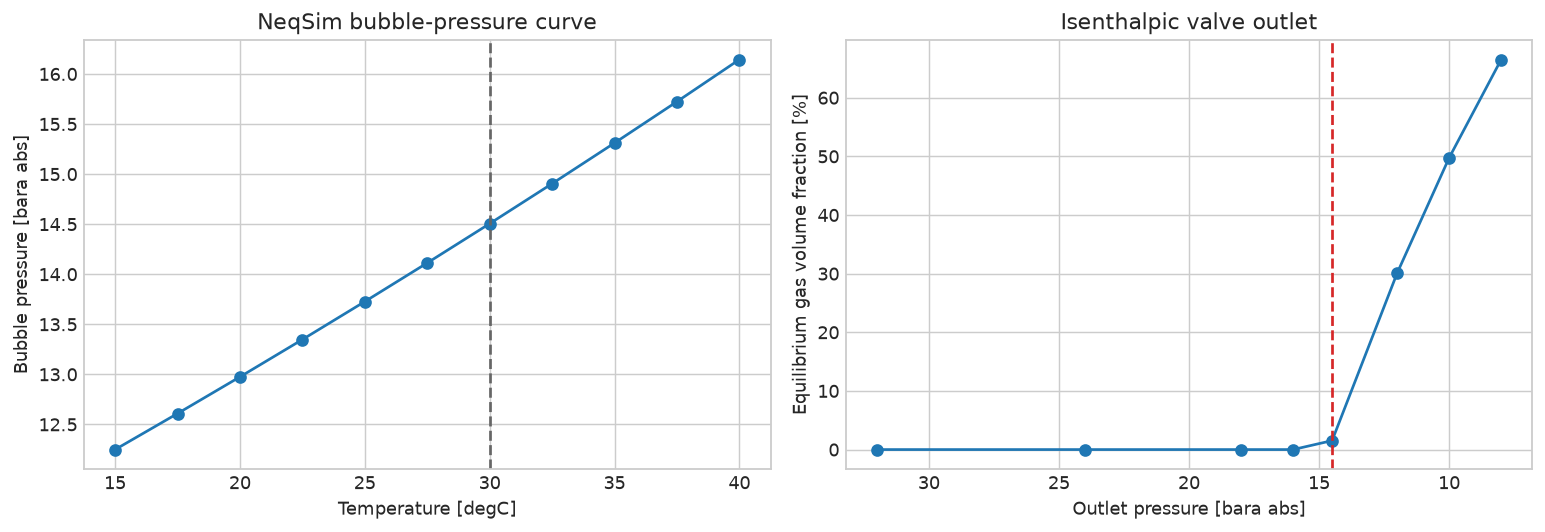

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(
    bubble_curve["temperature_degc"],
    bubble_curve["bubble_pressure_bara"],
    marker="o",
)
axes[0].axvline(TEMPERATURE_K - 273.15, color="0.4", linestyle="--")
axes[0].set(
    xlabel="Temperature [degC]",
    ylabel="Bubble pressure [bara abs]",
    title="NeqSim bubble-pressure curve",
)

axes[1].plot(
    flash_table["outlet_pressure_bara"],
    100.0 * flash_table["gas_volume_fraction"],
    marker="o",
)
axes[1].axvline(BUBBLE_PRESSURE_BARA, color="tab:red", linestyle="--")
axes[1].invert_xaxis()
axes[1].set(
    xlabel="Outlet pressure [bara abs]",
    ylabel="Equilibrium gas volume fraction [%]",
    title="Isenthalpic valve outlet",
)

fig.tight_layout()
plt.show()

process_valve_table

## 5. OpenFOAM model assumptions

The CFD cases are pressure-driven and share the same 1,920-cell planar restriction. The
inlet total pressure is 40 bara; only the outlet static pressure changes.

* Solver: OpenFOAM Foundation 14 `multiphaseEuler`.
* Phase transfer: Schnerr-Sauer with illustrative nuclei parameters
  $n=1.6\times10^{13}\ \mathrm{m^{-3}}$ and $d_{nuc}=2\ \mu\mathrm{m}$.
* Turbulence: phase-wise $k$-$\omega$ SST from the official hydrofoil tutorial.
* Thermodynamics: NeqSim $p_b(T)$ table, phase properties, and surface tension.
* Temperature: fixed at 303.15 K in this short CFD screen. NeqSim's PH flash supplies the
  separate thermal equilibrium reference.

The nuclei parameters require calibration for quantitative prediction. The fixed-temperature
assumption avoids over-interpreting phase-change heat transfer in a pseudo-component model.

In [7]:
def foam_environment():
    environment = os.environ.copy()
    library_root = (
        OPENFOAM_ROOT
        / "platforms"
        / OPENFOAM_PLATFORM
        / "lib"
    )
    binary_root = (
        OPENFOAM_ROOT
        / "platforms"
        / OPENFOAM_PLATFORM
        / "bin"
    )
    environment.update(
        {
            "WM_PROJECT_DIR": str(OPENFOAM_ROOT),
            "WM_PROJECT_VERSION": "14",
            "WM_PROJECT": "OpenFOAM",
            "FOAM_ETC": str(OPENFOAM_ROOT / "etc"),
            "FOAM_APPBIN": str(binary_root),
            "FOAM_LIBBIN": str(library_root),
            "FOAM_TUTORIALS": str(OPENFOAM_ROOT / "tutorials"),
            "PATH": (
                f"{binary_root}:{OPENFOAM_ROOT / 'bin'}:"
                f"{environment['PATH']}"
            ),
            "LD_LIBRARY_PATH": (
                f"{library_root / 'dummy'}:{library_root}:"
                f"{environment.get('LD_LIBRARY_PATH', '')}"
            ),
        }
    )
    return environment


def run_foam(command, case_dir, timeout_seconds=1_800):
    result = subprocess.run(
        command,
        cwd=case_dir,
        env=foam_environment(),
        check=True,
        text=True,
        capture_output=True,
        timeout=timeout_seconds,
    )
    return result


def write_velocity_field(path, phase_name, initial_velocity):
    path.write_text(
        f'''FoamFile
{{
    format ascii;
    class volVectorField;
    location "0";
    object U.{phase_name};
}}
dimensions [velocity];
internalField uniform ({initial_velocity} 0 0);
boundaryField
{{
    #includeEtc "caseDicts/setConstraintTypes"
    inlet
    {{
        type pressureInletOutletVelocity;
        phi phi.{phase_name};
        value uniform ({initial_velocity} 0 0);
    }}
    outlet
    {{
        type pressureInletOutletVelocity;
        phi phi.{phase_name};
        value uniform ({initial_velocity} 0 0);
    }}
    valveSeat {{ type noSlip; }}
    pipeWalls {{ type noSlip; }}
}}
'''
    )


def write_pressure_fields(case_dir, inlet_pressure_pa, outlet_pressure_pa):
    midpoint_pressure = 0.5 * (inlet_pressure_pa + outlet_pressure_pa)
    (case_dir / "0" / "p_rgh").write_text(
        f'''FoamFile
{{
    format ascii;
    class volScalarField;
    location "0";
    object p_rgh;
}}
dimensions [pressure];
internalField uniform {midpoint_pressure:.10g};
boundaryField
{{
    #includeEtc "caseDicts/setConstraintTypes"
    inlet
    {{
        type prghTotalPressure;
        U U.liquid;
        p0 uniform {inlet_pressure_pa:.10g};
        value uniform {inlet_pressure_pa:.10g};
    }}
    outlet
    {{
        type prghPressure;
        p uniform {outlet_pressure_pa:.10g};
        value uniform {outlet_pressure_pa:.10g};
    }}
    valveSeat {{ type fixedFluxPressure; }}
    pipeWalls {{ type fixedFluxPressure; }}
}}
'''
    )
    (case_dir / "0" / "p").write_text(
        f'''FoamFile
{{
    format ascii;
    class volScalarField;
    location "0";
    object p;
}}
dimensions [pressure];
internalField uniform {midpoint_pressure:.10g};
boundaryField
{{
    #includeEtc "caseDicts/setConstraintTypes"
    inlet {{ type calculated; value $internalField; }}
    outlet {{ type calculated; value $internalField; }}
    valveSeat {{ type calculated; value $internalField; }}
    pipeWalls {{ type calculated; value $internalField; }}
}}
'''
    )

In [8]:
def block_mesh_text():
    x_values = (-0.04, -0.006, 0.0, 0.006, 0.10)
    half_heights = (0.010, 0.010, 0.0025, 0.010, 0.010)
    depth = 0.001
    vertices = []
    for x_value, half_height in zip(x_values, half_heights):
        vertices.extend(
            [
                (x_value, -half_height, -depth / 2),
                (x_value, half_height, -depth / 2),
                (x_value, -half_height, depth / 2),
                (x_value, half_height, depth / 2),
            ]
        )
    vertex_lines = "\n".join(
        f"    ({x_value:.8g} {y_value:.8g} {z_value:.8g})"
        for x_value, y_value, z_value in vertices
    )

    x_cells = (24, 12, 12, 48)
    block_lines = []
    for segment, cells in enumerate(x_cells):
        left = 4 * segment
        right = 4 * (segment + 1)
        indices = (
            left,
            right,
            right + 1,
            left + 1,
            left + 2,
            right + 2,
            right + 3,
            left + 3,
        )
        block_lines.append(
            "    hex ("
            + " ".join(str(index) for index in indices)
            + f") ({cells} 20 1) simpleGrading (1 1 1)"
        )
    block_text = "\n".join(block_lines)

    pipe_faces = []
    seat_faces = []
    for segment in range(4):
        left = 4 * segment
        right = 4 * (segment + 1)
        bottom = f"({left} {left + 2} {right + 2} {right})"
        top = f"({left + 1} {right + 1} {right + 3} {left + 3})"
        target = seat_faces if segment in (1, 2) else pipe_faces
        target.extend((bottom, top))

    pipe_text = "\n            ".join(pipe_faces)
    seat_text = "\n            ".join(seat_faces)
    return f'''FoamFile
{{
    format ascii;
    class dictionary;
    object blockMeshDict;
}}
vertices
(
{vertex_lines}
);
blocks
(
{block_text}
);
edges ();
defaultPatch
{{
    name frontAndBack;
    type empty;
}}
boundary
(
    inlet
    {{
        type patch;
        faces ((0 1 3 2));
    }}
    outlet
    {{
        type patch;
        faces ((16 18 19 17));
    }}
    pipeWalls
    {{
        type wall;
        faces
        (
            {pipe_text}
        );
    }}
    valveSeat
    {{
        type wall;
        faces
        (
            {seat_text}
        );
    }}
);
'''


def openfoam_property_text():
    table_values = "\n".join(
        "                "
        f"({row.temperature_k:.5f} {row.bubble_pressure_pa:.8g})"
        for row in bubble_curve.itertuples()
    )
    gas_prandtl = (
        gas_phase.getCp("J/kgK")
        * gas_phase.getViscosity("kg/msec")
        / gas_phase.getThermalConductivity("W/mK")
    )
    liquid_prandtl = (
        liquid_phase.getCp("J/kgK")
        * liquid_phase.getViscosity("kg/msec")
        / liquid_phase.getThermalConductivity("W/mK")
    )
    fv_models = f'''FoamFile
{{
    format ascii;
    class dictionary;
    location "constant";
    object fvModels;
}}
phaseTurbulenceStabilisation
{{
    type phaseTurbulenceStabilisation;
    libs ("libmultiphaseEulerFvModels.so");
    phase gas;
    alphaInversion 0.1;
}}
cavitation
{{
    type multiphaseEuler::cavitation;
    libs ("libmultiphaseEulerFvModels.so");
    phases (liquid gas);
    energySemiImplicit yes;
    model SchnerrSauer;
    pSat
    {{
        type function1;
        function
        {{
            type table;
            values
            (
{table_values}
            );
            outOfBounds clamp;
            interpolationScheme linear;
        }}
    }}
    n 1.6e13;
    dNuc 2e-6;
    Cv 1;
    Cc 1;
}}
'''
    gas_properties = f'''FoamFile
{{
    format ascii;
    class dictionary;
    location "constant";
    object physicalProperties.gas;
}}
thermoType
{{
    type heRhoThermo;
    mixture pureMixture;
    transport const;
    thermo hConst;
    equationOfState perfectGas;
    specie specie;
    energy sensibleEnthalpy;
}}
mixture
{{
    specie {{ molWeight {1000.0 * gas_phase.getMolarMass():.9g}; }}
    thermodynamics
    {{
        Cp {gas_phase.getCp('J/kgK'):.9g};
        hf {latent_heat_j_per_kg:.9g};
    }}
    transport
    {{
        mu {gas_phase.getViscosity('kg/msec'):.9g};
        Pr {gas_prandtl:.9g};
    }}
}}
'''
    liquid_properties = f'''FoamFile
{{
    format ascii;
    class dictionary;
    location "constant";
    object physicalProperties.liquid;
}}
thermoType
{{
    type heRhoThermo;
    mixture pureMixture;
    transport const;
    thermo eConst;
    equationOfState rhoConst;
    specie specie;
    energy sensibleInternalEnergy;
}}
mixture
{{
    specie {{ molWeight {1000.0 * liquid_phase.getMolarMass():.9g}; }}
    equationOfState {{ rho {liquid_phase.getDensity('kg/m3'):.9g}; }}
    thermodynamics
    {{
        Cv {liquid_phase.getCv('J/kgK'):.9g};
        hf 0;
    }}
    transport
    {{
        mu {liquid_phase.getViscosity('kg/msec'):.9g};
        Pr {liquid_prandtl:.9g};
    }}
}}
'''
    return fv_models, gas_properties, liquid_properties

In [9]:
def replace_wall_patches(case_dir):
    for field_path in (case_dir / "0").iterdir():
        if not field_path.is_file():
            continue
        source = field_path.read_text()
        source = source.replace("hydrofoil", "valveSeat")
        source = source.replace("walls", "pipeWalls")
        field_path.write_text(source)


def build_case(case_dir, outlet_pressure_bara):
    template = OPENFOAM_ROOT / "tutorials" / "multiphaseEuler" / "hydrofoil"
    if case_dir.exists():
        shutil.rmtree(case_dir)
    shutil.copytree(template, case_dir)

    for removable in (
        case_dir / "constant" / "geometry",
        case_dir / "validation",
    ):
        if removable.exists():
            shutil.rmtree(removable)
    for name in ("Allrun", "Allclean"):
        target = case_dir / name
        if target.exists():
            target.unlink()

    replace_wall_patches(case_dir)
    for temperature_name in ("T.gas", "T.liquid"):
        temperature_path = case_dir / "0" / temperature_name
        temperature_path.write_text(
            temperature_path.read_text().replace("293.15", "303.15")
        )

    (case_dir / "system" / "blockMeshDict").write_text(block_mesh_text())
    write_velocity_field(case_dir / "0" / "U.gas.orig", "gas", 10.0)
    write_velocity_field(case_dir / "0" / "U.liquid.orig", "liquid", 10.0)
    write_pressure_fields(
        case_dir,
        INLET_PRESSURE_BARA * 1.0e5,
        outlet_pressure_bara * 1.0e5,
    )

    fv_models, gas_properties, liquid_properties = openfoam_property_text()
    (case_dir / "constant" / "fvModels").write_text(fv_models)
    (case_dir / "constant" / "physicalProperties.gas").write_text(
        gas_properties
    )
    (case_dir / "constant" / "physicalProperties.liquid").write_text(
        liquid_properties
    )

    phase_path = case_dir / "constant" / "phaseProperties"
    phase_text = phase_path.read_text().replace(
        "0.071",
        f"{surface_tension_n_per_m:.9g}",
    )
    phase_path.write_text(phase_text)

    gravity_path = case_dir / "constant" / "g"
    gravity_path.write_text(
        gravity_path.read_text().replace("(0 -9.81 0)", "(0 0 0)")
    )

    control_path = case_dir / "system" / "controlDict"
    control = control_path.read_text()
    control = control.replace("endTime         0.2;", "endTime         0.001;")
    control = control.replace("deltaT          2e-6;", "deltaT          1e-7;")
    control = control.replace(
        "writeInterval   0.01;",
        "writeInterval   0.00025;",
    )
    control = control.replace("writeFormat     binary;", "writeFormat     ascii;")
    control = control.replace("maxCo           0.8;", "maxCo           0.5;")
    control = control.replace("maxDeltaT       1e-4;", "maxDeltaT       2e-5;")
    control_path.write_text(control)

    solution_path = case_dir / "system" / "fvSolution"
    solution = solution_path.read_text()
    solution = solution.replace("nOuterCorrectors    3;", "nOuterCorrectors    2;")
    solution = solution.replace("nCorrectors         3;", "nCorrectors         2;")
    solution_path.write_text(solution)

    constraints_path = case_dir / "system" / "fvConstraints"
    constraints = constraints_path.read_text().replace(
        "min        1;",
        "min        10000;",
    )
    constraints = constraints.replace(
        "\n\n// ************************************************************************* //",
        '''

fixedLiquidTemperature
{
    type fixedTemperature;
    phase liquid;
    cellZone all;
    mode uniform;
    temperature constant 303.15;
}

fixedGasTemperature
{
    type fixedTemperature;
    phase gas;
    cellZone all;
    mode uniform;
    temperature constant 303.15;
}

// ************************************************************************* //''',
    )
    constraints_path.write_text(constraints)

    functions_path = case_dir / "system" / "functions"
    functions_path.write_text(
        '''FoamFile
{
    format ascii;
    class dictionary;
    object functions;
}
#includeFunc cellMin(name=min, alpha.gas, p, U.liquid, T.liquid)
#includeFunc cellMax(name=max, alpha.gas, p, U.liquid, T.liquid)
'''
    )


def initialize_and_run_case(case_dir, outlet_pressure_bara):
    build_case(case_dir, outlet_pressure_bara)
    mesh_result = run_foam(
        ["blockMesh", "-case", str(case_dir)],
        case_dir,
    )

    shutil.copy(case_dir / "0" / "U.liquid.orig", case_dir / "0" / "U")
    velocity_source = (case_dir / "0" / "U").read_text()
    velocity_source = velocity_source.replace("object U.liquid;", "object U;")
    velocity_source = velocity_source.replace("phi.liquid", "phi")
    (case_dir / "0" / "U").write_text(velocity_source)

    run_foam(
        ["potentialFoam", "-case", str(case_dir), "-pName", "p_rgh"],
        case_dir,
    )
    shutil.copy(case_dir / "0" / "U", case_dir / "0" / "U.gas")
    shutil.copy(case_dir / "0" / "U", case_dir / "0" / "U.liquid")
    for phase_name in ("gas", "liquid"):
        field_path = case_dir / "0" / f"U.{phase_name}"
        field_path.write_text(
            field_path.read_text().replace(
                "object U;",
                f"object U.{phase_name};",
            )
        )

    solution = run_foam(
        ["foamRun", "-case", str(case_dir), "-solver", "multiphaseEuler"],
        case_dir,
    )
    (case_dir / "log.foamRun").write_text(solution.stdout)
    run_foam(
        ["foamToVTK", "-case", str(case_dir), "-latestTime"],
        case_dir,
    )

    cell_match = [
        line
        for line in mesh_result.stdout.splitlines()
        if "cells:" in line
    ]
    if cell_match:
        return cell_match[-1].strip()
    return "1,920 cells"

## 6. Run three pressure regimes

Each case starts from the same potential-flow initialization and advances to 1 ms. This is
an early transient screening snapshot, chosen to make the Colab run practical. It is long
enough to distinguish vapor inception and outlet carry-through, but not a claim of statistical
stationarity or a converged valve-capacity coefficient.

In [10]:
CASE_ROOT = Path("/tmp/neqsim_openfoam_flashing_valve")
CASE_ROOT.mkdir(parents=True, exist_ok=True)

case_directories = {}
for outlet_pressure_bara in CFD_OUTLET_PRESSURES_BARA:
    label = f"p2_{outlet_pressure_bara:g}_bara"
    case_dir = CASE_ROOT / label
    mesh_summary = initialize_and_run_case(
        case_dir,
        outlet_pressure_bara,
    )
    case_directories[outlet_pressure_bara] = case_dir
    print(f"Completed {label}: {mesh_summary}")

Completed p2_32_bara: 1,920 cells
Completed p2_16_bara: 1,920 cells
Completed p2_8_bara: 1,920 cells


## 7. Post-process the CFD fields

The volume-weighted vapor fraction is more informative than a one-cell maximum. The outlet
area average distinguishes a collapsing local vapor pocket from sustained flashing.

In [11]:
def latest_vtk(path):
    candidates = list(path.glob("*.vtk"))
    return max(
        candidates,
        key=lambda item: int(item.stem.rsplit("_", 1)[-1]),
    )


def summarize_cfd_case(outlet_pressure_bara, case_dir):
    internal_path = latest_vtk(case_dir / "VTK")
    outlet_path = latest_vtk(case_dir / "VTK" / "outlet")

    mesh = pv.read(internal_path)
    outlet = pv.read(outlet_path)
    cells = mesh.cell_data
    outlet_cells = outlet.cell_data

    cell_volumes = mesh.compute_cell_sizes(
        length=False,
        area=False,
        volume=True,
    ).cell_data["Volume"]
    outlet_areas = outlet.compute_cell_sizes(
        length=False,
        area=True,
        volume=False,
    ).cell_data["Area"]
    velocity_magnitude = np.linalg.norm(cells["U.liquid"], axis=1)

    minimum_pressure_bara = float(np.min(cells["p"]) / 1.0e5)
    maximum_gas_fraction = float(np.max(cells["alpha.gas"]))
    mean_gas_fraction = float(
        np.average(cells["alpha.gas"], weights=cell_volumes)
    )
    outlet_gas_fraction = float(
        np.average(outlet_cells["alpha.gas"], weights=outlet_areas)
    )

    if maximum_gas_fraction < 1.0e-6:
        regime = "single-phase"
    elif outlet_gas_fraction < 1.0e-3:
        regime = "local cavitation / recovery"
    else:
        regime = "sustained flashing"

    return {
        "outlet_pressure_bara": outlet_pressure_bara,
        "minimum_pressure_bara": minimum_pressure_bara,
        "pressure_margin_bara": (
            minimum_pressure_bara - BUBBLE_PRESSURE_BARA
        ),
        "maximum_velocity_m_per_s": float(np.max(velocity_magnitude)),
        "maximum_gas_volume_fraction": maximum_gas_fraction,
        "volume_mean_gas_fraction": mean_gas_fraction,
        "outlet_mean_gas_fraction": outlet_gas_fraction,
        "CFD_regime": regime,
        "mesh": mesh,
    }


cfd_records = [
    summarize_cfd_case(pressure, case_directories[pressure])
    for pressure in CFD_OUTLET_PRESSURES_BARA
]
cfd_table = pd.DataFrame(
    [
        {key: value for key, value in record.items() if key != "mesh"}
        for record in cfd_records
    ]
)

cfd_table

,outlet_pressure_bara,minimum_pressure_bara,pressure_margin_bara,maximum_velocity_m_per_s,maximum_gas_volume_fraction,volume_mean_gas_fraction,outlet_mean_gas_fraction,CFD_regime
0,32,31.2358,16.7307,49.9072,0,0,0,single-phase
1,16,14.2437,-0.261403,91.1417,0.712538,0.00598258,0,local cavitation / recovery
2,8,14.1922,-0.312938,93.7381,0.849618,0.026476,0.741403,sustained flashing


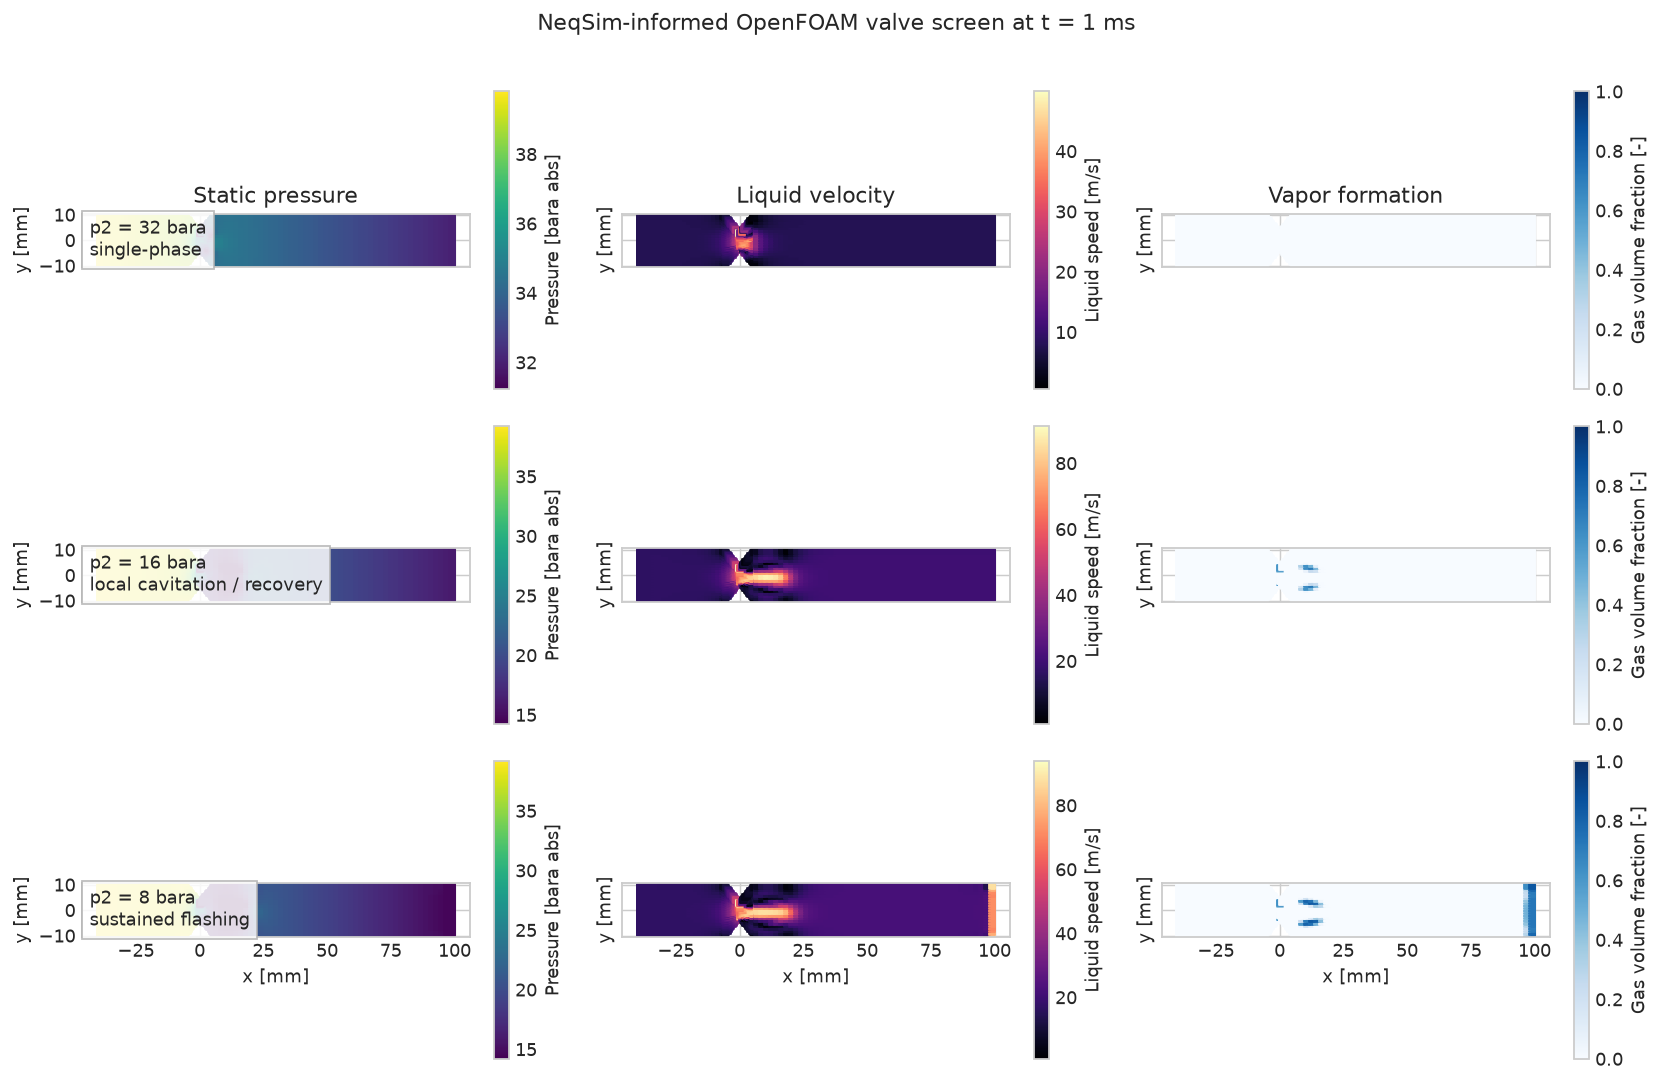

In [12]:
fig, axes = plt.subplots(
    len(cfd_records),
    3,
    figsize=(13, 8.2),
    sharex=True,
    sharey=True,
)

field_specs = (
    ("p", "Pressure [bara abs]", 1.0e-5, "viridis"),
    ("U.liquid", "Liquid speed [m/s]", None, "magma"),
    ("alpha.gas", "Gas volume fraction [-]", 1.0, "Blues"),
)

for row_index, record in enumerate(cfd_records):
    mesh = record["mesh"]
    centers = mesh.cell_centers().points
    x_values = centers[:, 0]
    y_values = centers[:, 1]

    for column_index, (field, label, scale, cmap) in enumerate(field_specs):
        values = mesh.cell_data[field]
        if field == "U.liquid":
            values = np.linalg.norm(values, axis=1)
        else:
            values = values * scale

        color_limits = {}
        if field == "alpha.gas":
            color_limits = {"vmin": 0.0, "vmax": 1.0}

        scatter = axes[row_index, column_index].scatter(
            1.0e3 * x_values,
            1.0e3 * y_values,
            c=values,
            cmap=cmap,
            s=11,
            marker="s",
            **color_limits,
        )
        colorbar = fig.colorbar(scatter, ax=axes[row_index, column_index])
        colorbar.set_label(label)
        axes[row_index, column_index].set_aspect("equal")
        axes[row_index, column_index].set_ylabel("y [mm]")
        if row_index == len(cfd_records) - 1:
            axes[row_index, column_index].set_xlabel("x [mm]")

    axes[row_index, 0].text(
        0.02,
        0.92,
        (
            f"p2 = {record['outlet_pressure_bara']:.0f} bara\n"
            f"{record['CFD_regime']}"
        ),
        transform=axes[row_index, 0].transAxes,
        va="top",
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "0.7"},
    )

axes[0, 0].set_title("Static pressure")
axes[0, 1].set_title("Liquid velocity")
axes[0, 2].set_title("Vapor formation")
fig.suptitle("NeqSim-informed OpenFOAM valve screen at t = 1 ms", y=1.01)
fig.tight_layout()
plt.show()

## 8. Interpretation

* **32 bara:** the entire CFD pressure field remains above the NeqSim bubble pressure, so
  no vapor is generated.
* **16 bara:** the throat pressure dips below the bubble pressure, producing a local vapor
  pocket, while the 16 bara outlet recovers above the bubble pressure and contains
  essentially no vapor.
* **8 bara:** the downstream pressure itself is below the bubble pressure, so vapor crosses
  the outlet. NeqSim independently predicts a two-phase isenthalpic outlet.

A high maximum vapor fraction in one cell is an inception indicator, not a valve damage
rate. Useful next-level checks include mesh and time-step refinement, longer transient
averaging, nuclei calibration, vapor residence time, pressure-pulsation spectra, and wall
pressure or collapse intensity near the seat.

## 9. Executable validation checks

These assertions verify thermodynamic closure, bounded fields, imposed pressure ordering,
and the expected qualitative regimes. They do not replace validation against a valve test.

In [13]:
assert NEQSIM_VERSION == NEQSIM_VERSION_REQUIRED
assert np.isclose(
    feed_fluid.getPressure("bara"),
    INLET_PRESSURE_BARA,
    atol=1.0e-9,
)
assert str(feed_phase.getPhaseTypeName()) == "oil"
assert 10.0 < BUBBLE_PRESSURE_BARA < 20.0
assert np.all(np.diff(bubble_curve["bubble_pressure_bara"]) > 0.0)
assert np.max(np.abs(flash_table["enthalpy_error_j_per_kg"])) < 1.0e-3

for record in cfd_records:
    assert 0.0 <= record["maximum_gas_volume_fraction"] <= 1.0 + 1.0e-8
    assert 0.0 <= record["outlet_mean_gas_fraction"] <= 1.0 + 1.0e-8
    assert record["minimum_pressure_bara"] < INLET_PRESSURE_BARA
    assert record["maximum_velocity_m_per_s"] > 0.0

expected_regimes = [
    "single-phase",
    "local cavitation / recovery",
    "sustained flashing",
]
assert cfd_table["CFD_regime"].tolist() == expected_regimes
assert process_valve_table.loc[
    process_valve_table["outlet_pressure_bara"] == 8.0,
    "gas_volume_fraction",
].iloc[0] > 0.5

validation_summary = pd.Series(
    {
        "composition sum": sum(LIQUID_COMPOSITION.values()),
        "bubble pressure [bara]": BUBBLE_PRESSURE_BARA,
        "maximum PH enthalpy error [J/kg]": np.max(
            np.abs(flash_table["enthalpy_error_j_per_kg"])
        ),
        "OpenFOAM cells per case": cfd_records[0]["mesh"].n_cells,
        "qualitative regimes passed": True,
    },
    name="validation",
)

validation_summary

composition sum                              1
bubble pressure [bara]                 14.5051
maximum PH enthalpy error [J/kg]   0.000156892
OpenFOAM cells per case                   1920
qualitative regimes passed                True
Name: validation, dtype: object

## 10. Simple example: import a 3D valve geometry

This second OpenFOAM example demonstrates the usual 3D CAD/STL route without repeating the
multiphase study. To keep **Run all** reproducible, the next cell writes a tiny example as
three STL surfaces: `walls.stl`, `inlet.stl`, and `outlet.stl`. OpenFOAM then imports those
files with `snappyHexMesh`.

NeqSim supplies the liquid density and dynamic viscosity at the 40 bara inlet. Their ratio
is the kinematic viscosity required by the incompressible OpenFOAM solver:

$$\nu = \frac{\mu}{\rho}.$$

To use an exported CAD model later, replace the three STL files while retaining the patch
names and one closed fluid region. This small example runs laminar, single-phase flow so the
geometry-import workflow remains easy to inspect.

In [14]:
LIQUID_DENSITY_3D_KG_PER_M3 = feed_phase.getDensity("kg/m3")
LIQUID_VISCOSITY_3D_PA_S = feed_phase.getViscosity("kg/msec")
LIQUID_KINEMATIC_VISCOSITY_M2_PER_S = (
    LIQUID_VISCOSITY_3D_PA_S / LIQUID_DENSITY_3D_KG_PER_M3
)
INLET_VELOCITY_3D_M_PER_S = 0.1


def triangle_normal(vertex_a, vertex_b, vertex_c):
    normal = np.cross(
        np.asarray(vertex_b) - vertex_a,
        np.asarray(vertex_c) - vertex_a,
    )
    magnitude = np.linalg.norm(normal)
    if magnitude == 0.0:
        return np.zeros(3)
    return normal / magnitude


def write_ascii_stl(path, triangles, solid_name):
    lines = [f"solid {solid_name}"]
    for triangle in triangles:
        normal = triangle_normal(*triangle)
        lines.append(
            "  facet normal "
            f"{normal[0]:.9g} {normal[1]:.9g} {normal[2]:.9g}"
        )
        lines.append("    outer loop")
        for vertex in triangle:
            lines.append(
                "      vertex "
                f"{vertex[0]:.9g} {vertex[1]:.9g} {vertex[2]:.9g}"
            )
        lines.extend(("    endloop", "  endfacet"))
    lines.append(f"endsolid {solid_name}")
    path.write_text("\n".join(lines) + "\n")


def create_example_stl_geometry(geometry_dir):
    x_values = np.array([-0.04, -0.006, 0.0, 0.006, 0.10])
    radii = np.array([0.010, 0.010, 0.003, 0.010, 0.010])
    theta_values = np.linspace(0.0, 2.0 * np.pi, 49)[:-1]
    rings = [
        [
            np.array(
                [
                    x_value,
                    radius * np.cos(theta),
                    radius * np.sin(theta),
                ]
            )
            for theta in theta_values
        ]
        for x_value, radius in zip(x_values, radii)
    ]

    wall_triangles = []
    for left_ring, right_ring in zip(rings[:-1], rings[1:]):
        for index in range(len(theta_values)):
            next_index = (index + 1) % len(theta_values)
            wall_triangles.extend(
                (
                    (
                        left_ring[index],
                        right_ring[index],
                        right_ring[next_index],
                    ),
                    (
                        left_ring[index],
                        right_ring[next_index],
                        left_ring[next_index],
                    ),
                )
            )

    inlet_center = np.array([x_values[0], 0.0, 0.0])
    outlet_center = np.array([x_values[-1], 0.0, 0.0])
    inlet_triangles = []
    outlet_triangles = []
    for index in range(len(theta_values)):
        next_index = (index + 1) % len(theta_values)
        inlet_triangles.append(
            (inlet_center, rings[0][next_index], rings[0][index])
        )
        outlet_triangles.append(
            (outlet_center, rings[-1][index], rings[-1][next_index])
        )

    write_ascii_stl(
        geometry_dir / "walls.stl",
        wall_triangles,
        "walls",
    )
    write_ascii_stl(
        geometry_dir / "inlet.stl",
        inlet_triangles,
        "inlet",
    )
    write_ascii_stl(
        geometry_dir / "outlet.stl",
        outlet_triangles,
        "outlet",
    )


property_transfer_3d = pd.Series(
    {
        "density [kg/m3]": LIQUID_DENSITY_3D_KG_PER_M3,
        "dynamic viscosity [Pa s]": LIQUID_VISCOSITY_3D_PA_S,
        "kinematic viscosity [m2/s]": (
            LIQUID_KINEMATIC_VISCOSITY_M2_PER_S
        ),
    },
    name="NeqSim to 3D OpenFOAM",
)

property_transfer_3d

density [kg/m3]                  587.445
dynamic viscosity [Pa s]     0.000197999
kinematic viscosity [m2/s]   3.37052e-07
Name: NeqSim to 3D OpenFOAM, dtype: float64

In [15]:
def write_3d_mesh_dictionaries(case_dir):
    (case_dir / "system" / "blockMeshDict").write_text(
        '''FoamFile
{
    format ascii;
    class dictionary;
    object blockMeshDict;
}
convertToMeters 1;
vertices
(
    (-0.045 -0.012 -0.012)
    ( 0.105 -0.012 -0.012)
    ( 0.105  0.012 -0.012)
    (-0.045  0.012 -0.012)
    (-0.045 -0.012  0.012)
    ( 0.105 -0.012  0.012)
    ( 0.105  0.012  0.012)
    (-0.045  0.012  0.012)
);
blocks
(
    hex (0 1 2 3 4 5 6 7) (75 12 12) simpleGrading (1 1 1)
);
edges ();
boundary ();
defaultPatch
{
    name background;
    type patch;
}
'''
    )
    (case_dir / "system" / "snappyHexMeshDict").write_text(
        '''FoamFile
{
    format ascii;
    class dictionary;
    object snappyHexMeshDict;
}
castellatedMesh true;
snap true;
addLayers false;
geometry
{
    walls { type triSurface; file "walls.stl"; }
    inlet { type triSurface; file "inlet.stl"; }
    outlet { type triSurface; file "outlet.stl"; }
}
castellatedMeshControls
{
    maxLocalCells 200000;
    maxGlobalCells 200000;
    minRefinementCells 0;
    maxLoadUnbalance 0.10;
    nCellsBetweenLevels 2;
    features ();
    refinementSurfaces
    {
        walls { level (1 1); patchInfo { type wall; } }
        inlet { level (1 1); patchInfo { type patch; } }
        outlet { level (1 1); patchInfo { type patch; } }
    }
    resolveFeatureAngle 30;
    refinementRegions {}
    insidePoint (0.05 0.001 0.001);
    allowFreeStandingZoneFaces false;
}
snapControls
{
    nSmoothPatch 3;
    tolerance 2.0;
    nSolveIter 30;
    nRelaxIter 5;
}
addLayersControls
{
    relativeSizes true;
    layers {};
    expansionRatio 1.0;
    finalLayerThickness 0.3;
    minThickness 0.1;
    nGrow 0;
    featureAngle 60;
    nRelaxIter 3;
    nSmoothSurfaceNormals 1;
    nSmoothNormals 3;
    nSmoothThickness 10;
    maxFaceThicknessRatio 0.5;
    maxThicknessToMedialRatio 0.3;
    minMedianAxisAngle 90;
    nBufferCellsNoExtrude 0;
    nLayerIter 50;
}
meshQualityControls
{
    #includeEtc "caseDicts/mesh/generation/meshQualityDict"
}
mergeTolerance 1e-6;
'''
    )


def write_3d_flow_dictionaries(case_dir):
    (case_dir / "0" / "U").write_text(
        f'''FoamFile
{{
    format ascii;
    class volVectorField;
    location "0";
    object U;
}}
dimensions [velocity];
internalField uniform (0 0 0);
boundaryField
{{
    inlet
    {{
        type fixedValue;
        value uniform ({INLET_VELOCITY_3D_M_PER_S:.9g} 0 0);
    }}
    outlet {{ type zeroGradient; }}
    walls {{ type noSlip; }}
    background {{ type noSlip; }}
}}
'''
    )
    (case_dir / "0" / "p").write_text(
        '''FoamFile
{
    format ascii;
    class volScalarField;
    location "0";
    object p;
}
dimensions [kinematicPressure];
internalField uniform 0;
boundaryField
{
    inlet { type zeroGradient; }
    outlet { type fixedValue; value uniform 0; }
    walls { type zeroGradient; }
    background { type zeroGradient; }
}
'''
    )
    (case_dir / "constant" / "physicalProperties").write_text(
        f'''FoamFile
{{
    format ascii;
    class dictionary;
    object physicalProperties;
}}
viscosityModel constant;
nu {LIQUID_KINEMATIC_VISCOSITY_M2_PER_S:.12g};
'''
    )
    (case_dir / "constant" / "momentumTransport").write_text(
        '''FoamFile
{
    format ascii;
    class dictionary;
    object momentumTransport;
}
simulationType laminar;
'''
    )
    (case_dir / "system" / "fvSchemes").write_text(
        '''FoamFile
{
    format ascii;
    class dictionary;
    object fvSchemes;
}
ddtSchemes { default steadyState; }
gradSchemes { default Gauss linear; }
divSchemes
{
    default none;
    div(phi,U) bounded Gauss upwind;
    div((nuEff*dev2(T(grad(U))))) Gauss linear;
}
laplacianSchemes { default Gauss linear limited 0.5; }
interpolationSchemes { default linear; }
snGradSchemes { default limited 0.5; }
'''
    )
    (case_dir / "system" / "fvSolution").write_text(
        '''FoamFile
{
    format ascii;
    class dictionary;
    object fvSolution;
}
solvers
{
    p
    {
        solver GAMG;
        tolerance 1e-9;
        relTol 0;
        smoother GaussSeidel;
    }
    Phi
    {
        solver GAMG;
        tolerance 1e-9;
        relTol 0;
        smoother GaussSeidel;
    }
    pcorr
    {
        solver GAMG;
        tolerance 1e-9;
        relTol 0;
        smoother GaussSeidel;
    }
    U
    {
        solver smoothSolver;
        smoother symGaussSeidel;
        tolerance 1e-9;
        relTol 0;
    }
}
SIMPLE
{
    nNonOrthogonalCorrectors 1;
    consistent yes;
    residualControl
    {
        p 1e-6;
        U 1e-6;
    }
}
relaxationFactors
{
    equations
    {
        U 0.5;
    }
}
'''
    )
    (case_dir / "system" / "controlDict").write_text(
        '''FoamFile
{
    format ascii;
    class dictionary;
    object controlDict;
}
solver incompressibleFluid;
startFrom startTime;
startTime 0;
stopAt endTime;
endTime 500;
deltaT 1;
writeControl timeStep;
writeInterval 500;
writeFormat ascii;
runTimeModifiable true;
'''
    )


def build_and_run_3d_case(case_dir):
    if case_dir.exists():
        shutil.rmtree(case_dir)
    (case_dir / "0").mkdir(parents=True)
    geometry_dir = case_dir / "constant" / "geometry"
    geometry_dir.mkdir(parents=True)
    (case_dir / "system").mkdir()

    create_example_stl_geometry(geometry_dir)
    imported_surfaces = {
        name: pv.read(geometry_dir / f"{name}.stl")
        for name in ("walls", "inlet", "outlet")
    }
    write_3d_mesh_dictionaries(case_dir)
    write_3d_flow_dictionaries(case_dir)

    run_foam(["blockMesh", "-case", str(case_dir)], case_dir)
    snappy = run_foam(
        ["snappyHexMesh", "-case", str(case_dir)],
        case_dir,
    )
    (case_dir / "log.snappyHexMesh").write_text(snappy.stdout)
    mesh_check = run_foam(["checkMesh", "-case", str(case_dir)], case_dir)
    (case_dir / "log.checkMesh").write_text(mesh_check.stdout)
    potential = run_foam(["potentialFoam", "-case", str(case_dir)], case_dir)
    (case_dir / "log.potentialFoam").write_text(potential.stdout)
    solution = run_foam(["foamRun", "-case", str(case_dir)], case_dir)
    (case_dir / "log.foamRun").write_text(solution.stdout)
    run_foam(
        ["foamToVTK", "-case", str(case_dir), "-time", "500"],
        case_dir,
    )
    return imported_surfaces, mesh_check.stdout

In [16]:
CASE_3D = CASE_ROOT / "imported_3d_valve"
imported_3d_surfaces, mesh_check_3d = build_and_run_3d_case(CASE_3D)


def postprocess_patch(case_dir, function_expression):
    result = run_foam(
        [
            "foamPostProcess",
            "-case",
            str(case_dir),
            "-func",
            function_expression,
            "-time",
            "500",
        ],
        case_dir,
    )
    value_line = [
        line
        for line in result.stdout.splitlines()
        if " of " in line and " = " in line
    ][-1]
    return float(value_line.rsplit(" = ", 1)[-1])


inlet_flow_3d_m3_per_s = postprocess_patch(
    CASE_3D,
    "patchFlowRate(patch=inlet)",
)
outlet_flow_3d_m3_per_s = postprocess_patch(
    CASE_3D,
    "patchFlowRate(patch=outlet)",
)
inlet_pressure_3d_m2_per_s2 = postprocess_patch(
    CASE_3D,
    "patchAverage(patch=inlet,fields=(p))",
)

vtk_3d_path = CASE_3D / "VTK" / f"{CASE_3D.name}_500.vtk"
mesh_3d = pv.read(vtk_3d_path)
speed_3d_m_per_s = np.linalg.norm(mesh_3d.cell_data["U"], axis=1)
pressure_drop_3d_pa = (
    inlet_pressure_3d_m2_per_s2 * LIQUID_DENSITY_3D_KG_PER_M3
)
flow_closure_3d_percent = (
    abs(abs(inlet_flow_3d_m3_per_s) - abs(outlet_flow_3d_m3_per_s))
    / abs(inlet_flow_3d_m3_per_s)
    * 100.0
)

cell_count_line_3d = [
    line.strip()
    for line in mesh_check_3d.splitlines()
    if line.strip().startswith("cells:")
][-1]
cell_count_3d = int(cell_count_line_3d.split(":", 1)[-1])

three_dimensional_summary = pd.Series(
    {
        "imported STL surfaces [-]": len(imported_3d_surfaces),
        "OpenFOAM cells [-]": cell_count_3d,
        "maximum velocity [m/s]": np.max(speed_3d_m_per_s),
        "pressure drop [Pa]": pressure_drop_3d_pa,
        "inlet flow [m3/s]": inlet_flow_3d_m3_per_s,
        "outlet flow [m3/s]": outlet_flow_3d_m3_per_s,
        "absolute flow imbalance [%]": flow_closure_3d_percent,
        "checkMesh result": "Mesh OK" if "Mesh OK" in mesh_check_3d else "review",
    },
    name="Imported 3D valve",
)

three_dimensional_summary

imported STL surfaces [-]                3
OpenFOAM cells [-]                   23024
maximum velocity [m/s]             1.06198
pressure drop [Pa]                 350.635
inlet flow [m3/s]             -2.95663e-05
outlet flow [m3/s]             2.95663e-05
absolute flow imbalance [%]              0
checkMesh result                   Mesh OK
Name: Imported 3D valve, dtype: object

3D STL import, mesh, flow, and validation checks passed.


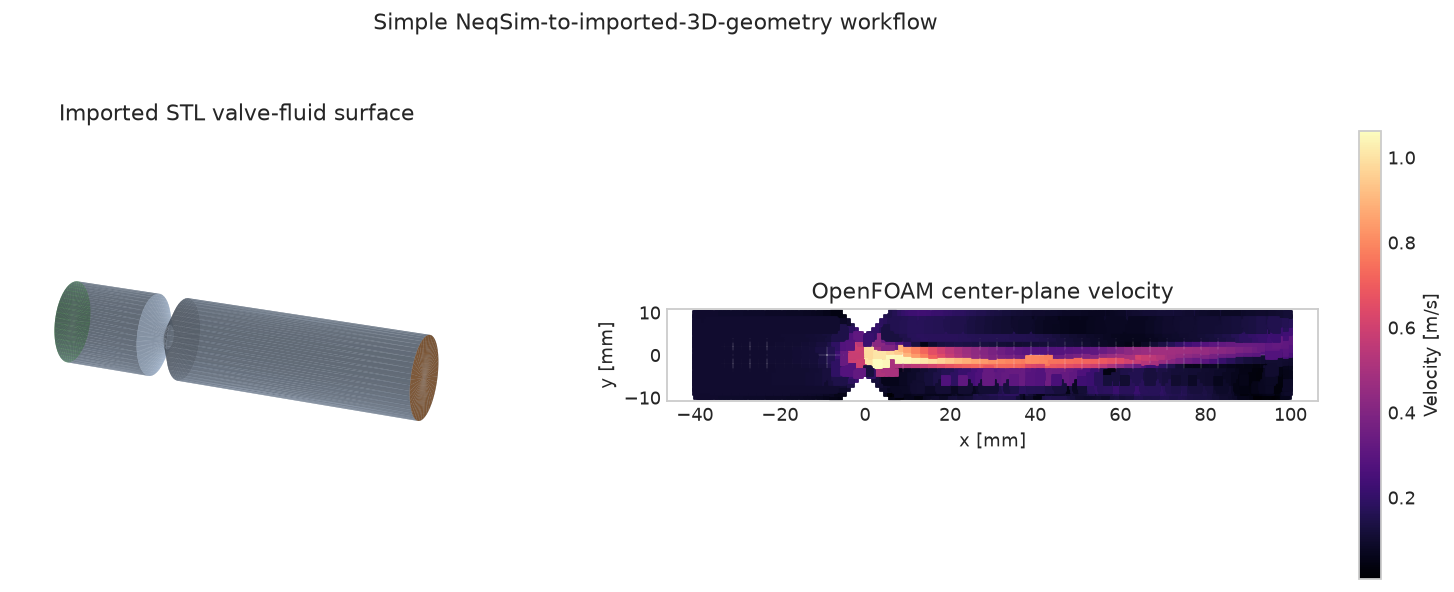

In [17]:
fig = plt.figure(figsize=(13, 4.6))
geometry_axis = fig.add_subplot(1, 2, 1, projection="3d")
slice_axis = fig.add_subplot(1, 2, 2)

surface_colors = {
    "walls": "lightsteelblue",
    "inlet": "tab:green",
    "outlet": "tab:orange",
}
for surface_name, surface in imported_3d_surfaces.items():
    triangles = surface.faces.reshape(-1, 4)[:, 1:]
    points_mm = 1.0e3 * surface.points
    geometry_axis.plot_trisurf(
        points_mm[:, 0],
        points_mm[:, 1],
        points_mm[:, 2],
        triangles=triangles,
        color=surface_colors[surface_name],
        alpha=0.75,
        linewidth=0.1,
    )
geometry_axis.set(
    xlabel="x [mm]",
    title="Imported STL valve-fluid surface",
)
geometry_axis.view_init(elev=20, azim=-65)
geometry_axis.set_box_aspect((5.0, 1.0, 1.0))
geometry_axis.set_axis_off()

center_slice_3d = mesh_3d.slice(normal="z", origin=(0.0, 0.0, 0.0))
slice_centers_3d = center_slice_3d.cell_centers().points
slice_speed_3d = np.linalg.norm(center_slice_3d.cell_data["U"], axis=1)
velocity_scatter = slice_axis.scatter(
    1.0e3 * slice_centers_3d[:, 0],
    1.0e3 * slice_centers_3d[:, 1],
    c=slice_speed_3d,
    cmap="magma",
    s=16,
    marker="s",
)
fig.colorbar(velocity_scatter, ax=slice_axis, label="Velocity [m/s]")
slice_axis.set(
    xlabel="x [mm]",
    ylabel="y [mm]",
    title="OpenFOAM center-plane velocity",
)
slice_axis.set_aspect("equal")
slice_axis.grid(False)

fig.suptitle("Simple NeqSim-to-imported-3D-geometry workflow", y=0.98)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.93))
plt.show()

assert len(imported_3d_surfaces) == 3
assert all(surface.n_cells > 0 for surface in imported_3d_surfaces.values())
assert "Mesh OK" in mesh_check_3d
assert 20_000 < cell_count_3d < 30_000
assert np.isclose(
    LIQUID_KINEMATIC_VISCOSITY_M2_PER_S,
    LIQUID_VISCOSITY_3D_PA_S / LIQUID_DENSITY_3D_KG_PER_M3,
    rtol=1.0e-12,
)
assert np.max(speed_3d_m_per_s) > 5.0 * INLET_VELOCITY_3D_M_PER_S
assert pressure_drop_3d_pa > 0.0
assert flow_closure_3d_percent < 1.0e-4

print("3D STL import, mesh, flow, and validation checks passed.")

## 11. How to adapt the examples

1. Replace `LIQUID_COMPOSITION`, temperature, and inlet pressure with a characterized fluid.
2. Recalculate the bubble curve and check that the inlet remains liquid.
3. Replace the idealized restriction with the actual trim geometry and operating opening.
4. Calibrate nuclei density and diameter using test data or a justified uncertainty range.
5. Run mesh, time-step, and duration sensitivities; monitor outlet vapor, wall pressure, and
   transient mass storage before using quantitative results.
6. For severe flashing, evaluate a compressible multicomponent or population-balance model,
   downstream piping, acoustics, vibration, and erosion with specialist methods.
7. For a 3D CAD model, export a watertight fluid volume as separate wall, inlet, and outlet
   STL patches. Check units and surface normals, update `insidePoint`, refine the background
   mesh, and repeat the `checkMesh` and mesh-independence checks.

## 12. References

* [NeqSim `ThrottlingValve` source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/equipment/valve/ThrottlingValve.java)
* [NeqSim bubble-point pressure flash source](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/thermodynamicoperations/flashops/saturationops/BubblePointPressureFlash.java)
* [OpenFOAM Foundation 14 Ubuntu installation](https://openfoam.org/download/14-ubuntu/)
* [OpenFOAM Foundation 14 release notes](https://openfoam.org/release/14/)
* [OpenFOAM multiphase solver overview](https://cfd.direct/openfoam/features/multiphase/)
* Schnerr, G. H. and Sauer, J. (2001), *Physical and Numerical Modeling of Unsteady
  Cavitation Dynamics*, Fourth International Conference on Multiphase Flow.

## 13. Exercises

1. Sweep outlet pressure from 12 to 20 bara and estimate the pressure at which vapor first
   reaches the valve outlet.
2. Repeat the bubble curve at 15 °C and 45 °C. Explain how temperature changes the safe
   pressure margin.
3. Double the cells in each direction and halve `maxCo`. Compare minimum pressure, volume-
   mean vapor fraction, and outlet vapor fraction.
4. Vary the nuclei density by one decade in each direction. Which conclusion is robust, and
   which vapor metrics are calibration-sensitive?
5. Replace the generated 3D STL files with a different smooth contraction. Compare the
   snappy mesh size, maximum velocity, and pressure drop.